In [26]:
# pip install torch_geometric

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.utils import to_networkx
from torch_geometric.loader import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import networkx as nx
import os
import random

In [28]:
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [30]:
class StructuralVLNDataset:
    def __init__(self, num_graphs=800, num_nodes=12, feature_dim=64):
        self.num_graphs = num_graphs
        self.num_nodes = num_nodes
        self.feature_dim = feature_dim
        self.data_list = []
        self._generate_data()

    def _generate_data(self):
        for i in range(self.num_graphs):
            num_nodes = self.num_nodes
            # Random semantic features (simulating CLIP)
            x = torch.randn(num_nodes, self.feature_dim)

            # Generate Positions based on Structure Type (Label)
            structure_type = random.choice([0, 1, 2])
            positions = torch.zeros(num_nodes, 3)

            if structure_type == 0:  # Linear (Corridor-like)
                positions[:, 0] = torch.linspace(0, 10, num_nodes)
                positions[:, 1] = torch.randn(num_nodes) * 0.2
            elif structure_type == 1:  # Clustered (Room-like)
                centers = torch.rand(2, 3) * 10
                for j in range(num_nodes):
                    center = centers[j % 2]
                    positions[j] = center + torch.randn(3) * 1.5
            else:  # Dispersed (Open Space)
                positions = torch.rand(num_nodes, 3) * 10

            # Build Edges based on spatial proximity
            edge_index = []
            threshold_dist = 3.0
            for j in range(num_nodes):
                for k in range(j + 1, num_nodes):
                    dist = torch.norm(positions[j] - positions[k])
                    if dist < threshold_dist:
                        edge_index.append([j, k])
                        edge_index.append([k, j])

            if len(edge_index) == 0: continue

            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            y = torch.tensor([structure_type], dtype=torch.long)

            data = Data(x=x, edge_index=edge_index, y=y, pos=positions)
            self.data_list.append(data)

    def get_split(self, train_ratio=0.8):
        random.shuffle(self.data_list)
        split_idx = int(len(self.data_list) * train_ratio)
        return self.data_list[:split_idx], self.data_list[split_idx:]

In [31]:
class BaselineZoneAggregator(nn.Module):
    """Baseline: MLP + Pooling (No Graph Reasoning)"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.classifier = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, batch = data.x, data.batch
        x = self.mlp(x)
        x = global_mean_pool(x, batch)
        return F.log_softmax(self.classifier(x), dim=1)

In [32]:
class ProposedGNN(nn.Module):
    """Full Proposed Model: GAT + Input Proj + 2 Layers"""
    def __init__(self, input_dim, hidden_dim, output_dim, heads=4, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.conv1 = GATConv(hidden_dim, hidden_dim, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=False, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.input_proj(x)
        x = F.relu(x)
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        return F.log_softmax(self.classifier(x), dim=1)

In [33]:
class Ablation_NoAttention(nn.Module):
    """Ablation 1: Replace GAT with GCN (No Attention Weights)"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.input_proj(x)
        x = F.relu(x)
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        return F.log_softmax(self.classifier(x), dim=1)

In [34]:
class Ablation_Shallow(nn.Module):
    """Ablation 2: Single GNN Layer (Limited Receptive Field)"""
    def __init__(self, input_dim, hidden_dim, output_dim, heads=4):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.conv1 = GATConv(hidden_dim, hidden_dim, heads=heads, concat=False)
        self.classifier = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.input_proj(x)
        x = F.relu(x)
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        return F.log_softmax(self.classifier(x), dim=1)

In [35]:
def train_and_evaluate(model_class, train_data, test_data, epochs=30, lr=0.005, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    model = model_class(input_dim=64, hidden_dim=128, output_dim=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()

    best_acc = 0
    for epoch in range(epochs):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                out = model(data)
                preds.extend(out.argmax(dim=1).cpu().numpy())
                labels.extend(data.y.cpu().numpy())

        acc = accuracy_score(labels, preds)
        if acc > best_acc: best_acc = acc

    return best_acc

In [36]:
# Prepare Data Once
dataset = StructuralVLNDataset(num_graphs=800, feature_dim=64)
train_data, test_data = dataset.get_split()

seeds = [42, 123, 456, 789, 101]
results = {
    'Baseline (MLP)': [],
    'Proposed (GAT-2L)': [],
    'Ablation (GCN-NoAtt)': [],
    'Ablation (GAT-1L)': []
}

models_to_test = {
    'Baseline (MLP)': BaselineZoneAggregator,
    'Proposed (GAT-2L)': ProposedGNN,
    'Ablation (GCN-NoAtt)': Ablation_NoAttention,
    'Ablation (GAT-1L)': Ablation_Shallow
}

print("Running Experiments across 5 Seeds...")
for seed in seeds:
    print(f"--- Seed: {seed} ---")
    for name, model_cls in models_to_test.items():
        acc = train_and_evaluate(model_cls, train_data, test_data, seed=seed)
        results[name].append(acc)
        print(f"{name}: {acc:.4f}")

Running Experiments across 5 Seeds...
--- Seed: 42 ---
Baseline (MLP): 0.4062
Proposed (GAT-2L): 0.8000
Ablation (GCN-NoAtt): 0.8750
Ablation (GAT-1L): 0.7000
--- Seed: 123 ---
Baseline (MLP): 0.3937
Proposed (GAT-2L): 0.7937
Ablation (GCN-NoAtt): 0.8875
Ablation (GAT-1L): 0.7000
--- Seed: 456 ---
Baseline (MLP): 0.3875
Proposed (GAT-2L): 0.7688
Ablation (GCN-NoAtt): 0.8812
Ablation (GAT-1L): 0.6813
--- Seed: 789 ---
Baseline (MLP): 0.3688
Proposed (GAT-2L): 0.7438
Ablation (GCN-NoAtt): 0.8688
Ablation (GAT-1L): 0.7125
--- Seed: 101 ---
Baseline (MLP): 0.3875
Proposed (GAT-2L): 0.7812
Ablation (GCN-NoAtt): 0.8688
Ablation (GAT-1L): 0.7063


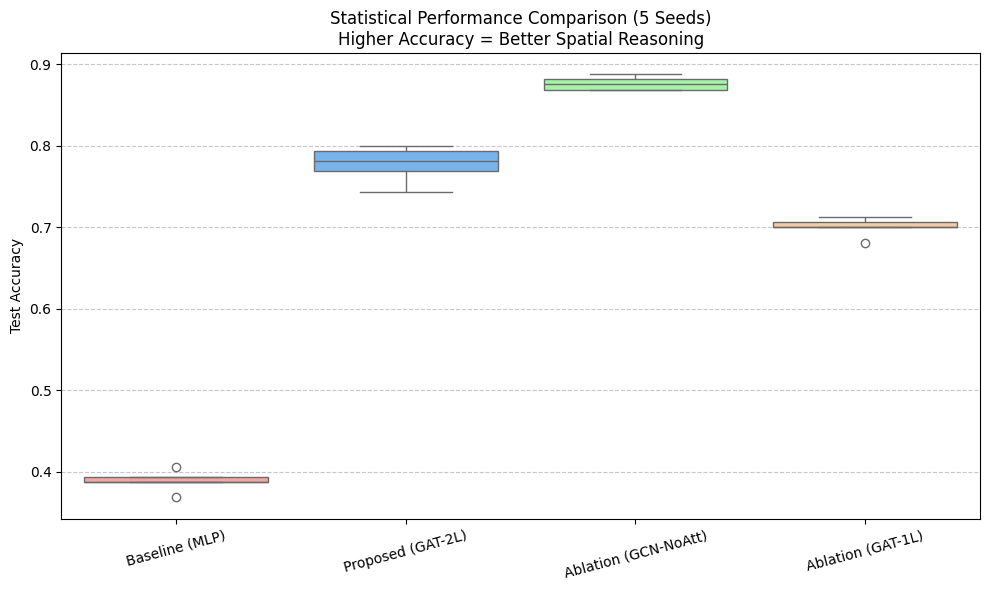

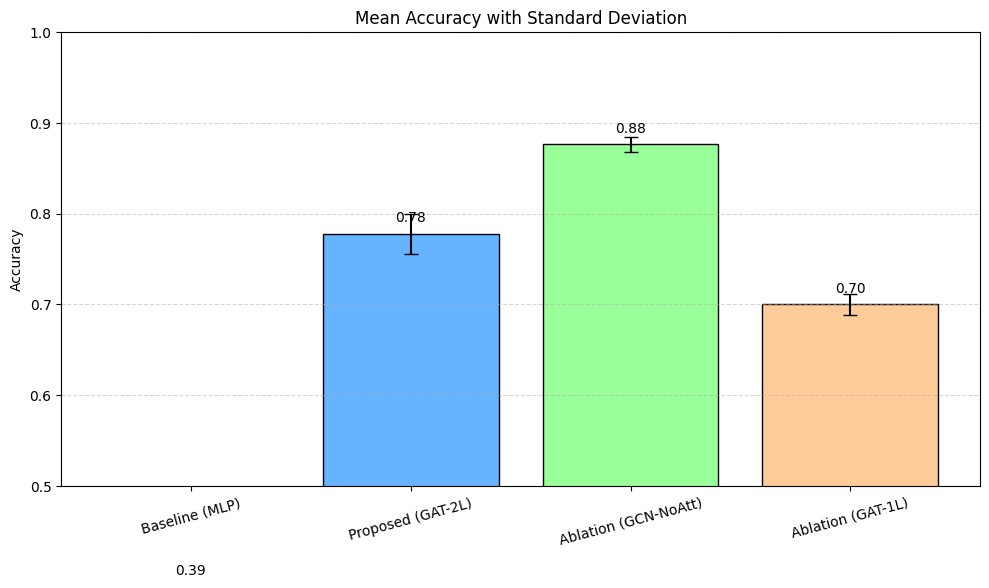


--- Final Ablation Results ---
                      Mean Accuracy  Std Dev
Baseline (MLP)               0.3888   0.0135
Proposed (GAT-2L)            0.7775   0.0224
Ablation (GCN-NoAtt)         0.8762   0.0081
Ablation (GAT-1L)            0.7000   0.0117


In [37]:
df_results = pd.DataFrame(results)

# 1. Statistical Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_results, palette=["#ff9999","#66b3ff","#99ff99","#ffcc99"])
plt.title('Statistical Performance Comparison (5 Seeds)\nHigher Accuracy = Better Spatial Reasoning')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ablation_boxplot.png', dpi=300)
plt.show()

# 2. Mean Performance Bar Chart
means = df_results.mean()
stds = df_results.std()

plt.figure(figsize=(10, 6))
bars = plt.bar(means.index, means, yerr=stds, capsize=5, color=["#ff9999","#66b3ff","#99ff99","#ffcc99"], edgecolor='black')
plt.title('Mean Accuracy with Standard Deviation')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.savefig('ablation_bar_chart.png', dpi=300)
plt.show()

# Print Summary Table
summary_df = pd.DataFrame({
    'Mean Accuracy': means,
    'Std Dev': stds
})
print("\n--- Final Ablation Results ---")
print(summary_df.round(4))